# HARI 4: Supervised Learning - Classification Path
Selamat datang di puncak perjalanan *bootcamp* kita! Hari ini kita akan membangun sistem pakar AI yang mampu melakukan **Klasifikasi** (membedakan kategori), bukan lagi menebak harga.

### Metodologi Standar Industri: CRISP-DM
Sesuai standar global, kita akan membedah proyek ini menggunakan kerangka **CRISP-DM**:
1. **Business Understanding:** Mendefinisikan masalah medis dan tujuan.
2. **Data Understanding:** Audit anatomi rekam medis dan visualisasi pola.
3. **Data Preparation:** Normalisasi skala angka dan *Data Splitting*.
4. **Modeling:** Melatih dan menyimulasikan isi kepala Logistic Regression, KNN, dan SVM.
5. **Evaluation:** Mengukur *Confusion Matrix* dan *Recall* (Menyelamatkan nyawa).

In [ ]:
# Import library standar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import library Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, classification_report

sns.set_theme(style="whitegrid")
print("✅ Library Klasifikasi Medis siap digunakan!")

✅ Library Klasifikasi Medis siap digunakan!


## BAB 1: Business Understanding

**Studi Kasus: Deteksi Dini Penyakit Jantung (Heart Disease Detection)**
Rumah sakit membutuhkan sistem triase pintar untuk membantu dokter IGD membaca rekam medis secara instan. Kesalahan membaca gejala bisa berakibat fatal (pasien sakit disuruh pulang).

* **Tujuan Utama (Goal):** Menciptakan model Machine Learning yang mampu mengklasifikasikan apakah seorang pasien **Sehat (0)** atau **Sakit Jantung (1)**.
* **Pendekatan AI:** `Supervised Learning - Binary Classification`. Karena target prediksinya ($Y$) berupa label kategori (0 atau 1), bukan rentang angka.

## BAB 2: Data Understanding
Mari kita panggil data rekam medis, melihat statistik dasarnya, dan mencari tahu gejala mana yang paling kuat hubungannya dengan penyakit jantung.

In [ ]:
# Panggil Dataset
url_heart = "https://raw.githubusercontent.com/kb22/Heart-Disease-Prediction/master/dataset.csv"
df = pd.read_csv(url_heart)

# Cek Dimensi dan Data Kosong
print(f"Banyak Pasien: {df.shape[0]} | Banyak Fitur Medis: {df.shape[1]}")
print(f"Data Kosong (Missing Values): {df.isnull().sum().sum()} buah\n")

# Distribusi Target (Apakah datanya seimbang?)
distribusi = df['target'].value_counts(normalize=True) * 100
print(f"Pasien Sakit (1) : {distribusi[1]:.1f}%")
print(f"Pasien Sehat (0) : {distribusi[0]:.1f}%\n")

# 4. Statistik Deskriptif
display(df[['age', 'trestbps', 'chol', 'thalach']].describe().T)

Banyak Pasien: 303 | Banyak Fitur Medis: 14
Data Kosong (Missing Values): 0 buah

Pasien Sakit (1) : 54.5%
Pasien Sehat (0) : 45.5%



,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0


### 2.1 Analisis Visual: Heatmap Korelasi
Apakah benar detak jantung maksimal (`thalach`) dan nyeri dada (`cp`) adalah gejala paling mematikan? Kita buktikan pakai *Heatmap* untuk melihat skor korelasi dengan target.

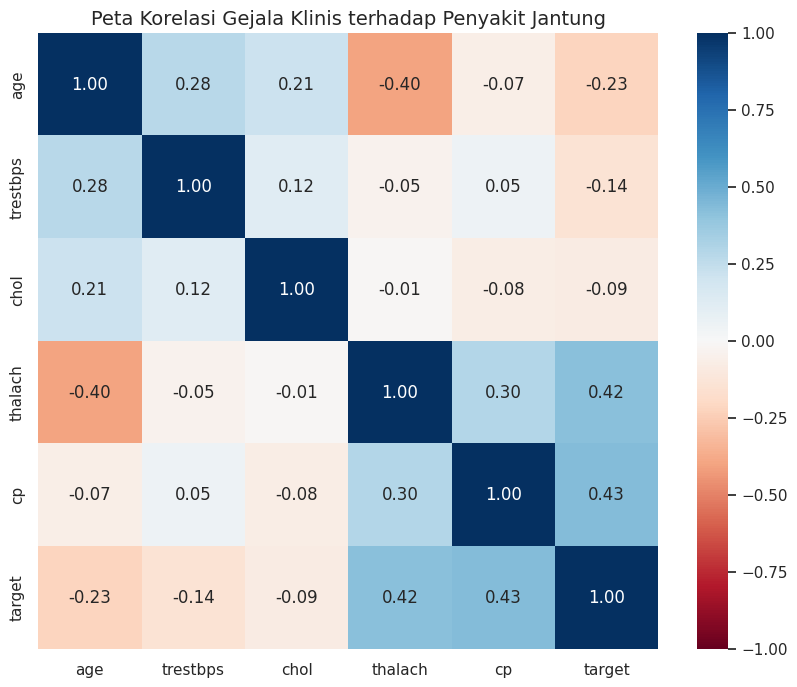

In [ ]:
plt.figure(figsize=(10, 8))

# Membuat matriks korelasi khusus untuk beberapa fitur utama
fitur_utama = ['age', 'trestbps', 'chol', 'thalach', 'cp', 'target']
korelasi = df[fitur_utama].corr()

# Menggambar Heatmap
sns.heatmap(korelasi, annot=True, cmap='RdBu', fmt='.2f', vmin=-1, vmax=1)
plt.title('Peta Korelasi Gejala Klinis terhadap Penyakit Jantung', fontsize=14)
plt.show()

# INSIGHT:
# 1. 'cp' (Nyeri Dada) punya korelasi positif cukup kuat (0.43). Artinya makin parah nyeri dada, peluang sakit makin tinggi.
# 2. 'thalach' (Detak Jantung Max) punya korelasi positif (0.42).
# 3. 'age' (Usia) justru punya korelasi negatif tipis (-0.23). AI kita akan mempelajari interaksi rumit ini!

## BAB 3: Data Preparation
Di algoritma Klasifikasi (terutama KNN dan SVM), mesin menghitung jarak antar titik data menggunakan geometri. Jika kita tidak menyamakan skala angkanya, fitur dengan nominal ribuan akan "menjajah" fitur yang desimal.

Kita akan menggunakan **Standard Scaler (Z-Score Normalization)**:
$$z = \frac{x - \mu}{\sigma}$$
Rumus ini akan menekan semua angka di dataset kita agar memiliki nilai rata-rata 0 dan variansi 1.

In [ ]:
# Pisahkan Fitur (X) dan Target (y)
X = df.drop('target', axis=1)
y = df['target']

# Train-Test Split (80% Belajar, 20% Ujian)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standarisasi Skala (Scaling)
scaler = StandardScaler()

# Mesin belajar mengenali skala dari Data Train, lalu mentransformasikannya
X_train_scaled = scaler.fit_transform(X_train)
# Data Test HANYA ditransformasi (tidak boleh di-fit agar tidak curang/bocor)
X_test_scaled = scaler.transform(X_test)

# Membuktikan hasil Scaling
print("Contoh Data Asli (Sebelum Scaling) - Kolesterol angkanya 200-an:")
display(X_train.head(2)[['age', 'chol']])

print("\nContoh Data Baru (Setelah Scaling) - Semua angka jadi seragam di sekitar 0:")
display(pd.DataFrame(X_train_scaled, columns=X.columns).head(2)[['age', 'chol']])

Contoh Data Asli (Sebelum Scaling) - Kolesterol angkanya 200-an:


,age,chol
132,42,295
202,58,270



Contoh Data Baru (Setelah Scaling) - Semua angka jadi seragam di sekitar 0:


,age,chol
0,-1.356798,0.914034
1,0.385086,0.439527


## BAB 4: Modeling (Menyimulasikan 3 Algoritma)
Saatnya menyekolahkan 3 Dokter Digital kita. Kita tidak akan langsung menebak hasil akhir, tapi kita akan bongkar rahasia bagaimana mereka mengambil keputusan!

### 4.1 Logistic Regression (Pembaca Bobot Gejala)
Logistic Regression bekerja dengan memberikan "Bobot Kepentingan" (Koefisien) pada setiap gejala. Mari kita lihat gejala mana yang paling dicurigai oleh dokter ini!

In [ ]:
# Training Model
model_logreg = LogisticRegression()
model_logreg.fit(X_train_scaled, y_train)

# MEMBONGKAR RUMUS: Gejala apa yang paling menentukan?
bobot = model_logreg.coef_[0]
df_bobot = pd.DataFrame({'Gejala Medis': X.columns, 'Kekuatan Pengaruh': bobot})
df_bobot = df_bobot.sort_values(by='Kekuatan Pengaruh', ascending=False)

print("--- LAPORAN LOGISTIC REGRESSION ---")
print("3 Gejala Utama Pemicu 'SAKIT JANTUNG' (Bobot Positif Tertinggi):")
display(df_bobot.head(3))

print("\n3 Gejala Penanda 'SEHAT' (Bobot Negatif Tertinggi):")
display(df_bobot.tail(3))

--- LAPORAN LOGISTIC REGRESSION ---
3 Gejala Utama Pemicu 'SAKIT JANTUNG' (Bobot Positif Tertinggi):


,Gejala Medis,Kekuatan Pengaruh
2,cp,0.817904
10,slope,0.435302
7,thalach,0.395131



3 Gejala Penanda 'SEHAT' (Bobot Negatif Tertinggi):


,Gejala Medis,Kekuatan Pengaruh
9,oldpeak,-0.681396
1,sex,-0.783086
11,ca,-0.789955


### 4.2 K-Nearest Neighbors / KNN (Sistem Voting Tetangga)
KNN tidak punya rumus bobot. Ia mendiagnosa pasien baru dengan cara mencari 5 pasien masa lalu yang rekam medisnya **paling persis (jaraknya paling dekat)** dengan pasien baru ini. Mari kita simulasi mencari tetangganya!

In [ ]:
# Training Model
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)

# MEMBONGKAR SISTEM VOTING
pasien_baru = X_test_scaled[0].reshape(1, -1)
jarak, indeks = model_knn.kneighbors(pasien_baru)

print("--- SIDANG KONSENSUS 5 TETANGGA (KNN) ---")
for i in range(5):
    id_tetangga = indeks[0][i]
    status_tetangga = y_train.iloc[id_tetangga]
    jarak_kedekatan = jarak[0][i]
    print(f"Tetangga {i+1} (Jarak kemiripan: {jarak_kedekatan:.2f}) ➔ Status Asli: {'SAKIT' if status_tetangga==1 else 'SEHAT'}")

vonis_akhir = model_knn.predict(pasien_baru)[0]
print(f"\nKeputusan Final KNN (Suara Terbanyak): {'SAKIT (1)' if vonis_akhir==1 else 'SEHAT (0)'}")

--- SIDANG KONSENSUS 5 TETANGGA (KNN) ---
Tetangga 1 (Jarak kemiripan: 2.48) ➔ Status Asli: SEHAT
Tetangga 2 (Jarak kemiripan: 3.04) ➔ Status Asli: SEHAT
Tetangga 3 (Jarak kemiripan: 3.15) ➔ Status Asli: SEHAT
Tetangga 4 (Jarak kemiripan: 3.17) ➔ Status Asli: SEHAT
Tetangga 5 (Jarak kemiripan: 3.20) ➔ Status Asli: SEHAT

Keputusan Final KNN (Suara Terbanyak): SEHAT (0)


### 4.3 Support Vector Machine (Garis Batas Ekstrem)
SVM hanya peduli pada pasien-pasien dengan gejala "abu-abu" (yang kondisinya hampir sehat tapi hampir sakit). Pasien-pasien perbatasan ini dijadikan tiang pancang yang dinamakan **Support Vectors**.

In [ ]:
# Training Model (Kernel linear agar bisa dibedah)
model_svm = SVC(kernel='linear', random_state=42)
model_svm.fit(X_train_scaled, y_train)

# MEMBONGKAR SUPPORT VECTORS
jumlah_sv = model_svm.n_support_
print("--- STRUKTUR PEMBATAS SVM ---")
print(f"Dari {len(X_train)} pasien latihan, SVM hanya menggunakan sebagian kecil untuk membuat batas tegas.")
print(f"1. Tiang Penyangga dari Kelompok Sehat : {jumlah_sv[0]} pasien ekstrem")
print(f"2. Tiang Penyangga dari Kelompok Sakit : {jumlah_sv[1]} pasien ekstrem")
print(f"Total Support Vectors: {sum(jumlah_sv)} pasien yang menentukan nasib semua tebakan!")

--- STRUKTUR PEMBATAS SVM ---
Dari 242 pasien latihan, SVM hanya menggunakan sebagian kecil untuk membuat batas tegas.
1. Tiang Penyangga dari Kelompok Sehat : 47 pasien ekstrem
2. Tiang Penyangga dari Kelompok Sakit : 50 pasien ekstrem
Total Support Vectors: 97 pasien yang menentukan nasib semua tebakan!


## BAB 5: Evaluation (Membaca Rapor Kejujuran AI)
Nyawa manusia tidak bisa hanya dinilai dari "Akurasi". Kita akan menggunakan **Confusion Matrix** untuk melihat di mana letak kelemahan AI.

*Fokus Utama Kita:* Menekan angka **False Negative (FN)** alias Pasien Sakit yang malah ditebak Sehat. Indikator metrik untuk mengukur hal ini adalah **RECALL**.

In [ ]:
# Menyuruh ketiga AI mendiagnosa seluruh pasien di data ujian (Test Set)
pred_logreg = model_logreg.predict(X_test_scaled)
pred_knn = model_knn.predict(X_test_scaled)
pred_svm = model_svm.predict(X_test_scaled)

print("Prediksi masal selesai dilakukan!")

Prediksi masal selesai dilakukan!


### 5.1 Visualisasi Confusion Matrix (Pengecekan False Negative)
Mari kita visualisasikan rapor *Confusion Matrix* dari **Logistic Regression** sebagai contoh utama.

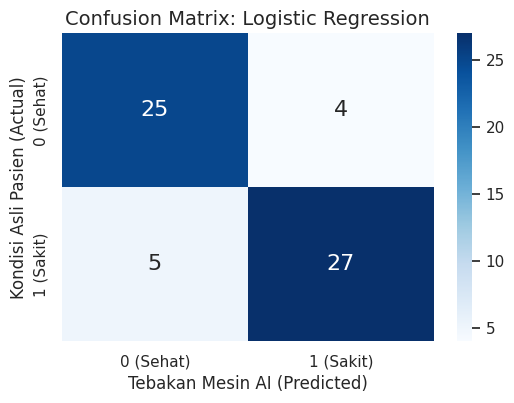

In [ ]:
# Membuat Confusion Matrix untuk Logistic Regression
cm = confusion_matrix(y_test, pred_logreg)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})

plt.title('Confusion Matrix: Logistic Regression', fontsize=14)
plt.xlabel('Tebakan Mesin AI (Predicted)')
plt.ylabel('Kondisi Asli Pasien (Actual)')
plt.xticks([0.5, 1.5], ['0 (Sehat)', '1 (Sakit)'])
plt.yticks([0.5, 1.5], ['0 (Sehat)', '1 (Sakit)'])
plt.show()

# CARA MEMBACA:
# Kanan Atas (FP): Pasien Sehat tapi ditebak Sakit (Panik)
# Kiri Bawah (FN): Pasien Sakit tapi ditebak Sehat (KECELAKAAN FATAL!)

### 5.2 Pertarungan Puncak: Akurasi vs Recall
Mari kita tandingkan ketiga algoritma ini! Siapa yang memegang skor Akurasi tertinggi, dan yang terpenting: Siapa yang memegang skor **Recall** tertinggi?

,Model,Akurasi (%),RECALL (%)
0,Logistic Regression,85.25,84.38
1,KNN,90.16,87.50
2,SVM (Linear),86.89,87.50


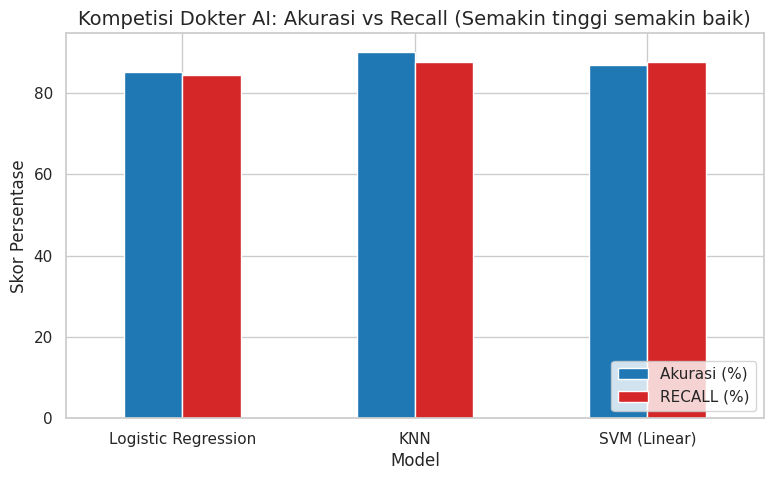

In [ ]:
# Menghitung Skor
skor = {
    'Model': ['Logistic Regression', 'KNN', 'SVM (Linear)'],
    'Akurasi (%)': [
        accuracy_score(y_test, pred_logreg)*100,
        accuracy_score(y_test, pred_knn)*100,
        accuracy_score(y_test, pred_svm)*100
    ],
    'RECALL (%)': [
        recall_score(y_test, pred_logreg)*100,
        recall_score(y_test, pred_knn)*100,
        recall_score(y_test, pred_svm)*100
    ]
}

df_skor = pd.DataFrame(skor)
display(df_skor.round(2))

# Visualisasi Papan Skor
df_skor.set_index('Model').plot(kind='bar', figsize=(9, 5), color=['#1f77b4', '#d62728'])
plt.title('Kompetisi Dokter AI: Akurasi vs Recall (Semakin tinggi semakin baik)', fontsize=14)
plt.ylabel('Skor Persentase')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

# KESIMPULAN
# Model dengan RECALL tertinggi adalah pemenangnya!
# Karena dalam dunia medis, menghindari False Negative (pasien terlewat) jauh lebih penting
# daripada memaksakan Akurasi semata.

# KESIMPULAN HARI KE-4 & AKHIR BOOTCAMP
Selamat! Anda telah resmi menjadi seorang pengembang Kecerdasan Buatan!
Hari ini Anda berhasil membedakan konsep dasar antara Regresi (Menebak harga) dan Klasifikasi (Menebak kelompok). Anda juga memahami bahwa dalam konteks bisnis dan kesehatan, metrik **Recall** dan analisis **Confusion Matrix** jauh lebih berharga daripada sekadar angka akurasi kosong.

### TAKE-HOME MISSION (Mencari Parameter Terbaik KNN)
Algoritma KNN kita tadi menggunakan aturan 5 tetangga terdekat (`n_neighbors=5`). Tugas eksplorasi Anda:
1. Ganti parameter *K* pada algoritma KNN menjadi `n_neighbors=3`.
2. Ganti lagi menjadi `n_neighbors=7`.
3. Jalankan ulang kodenya dan lihat, pada nilai *K*  berapakah skor **Recall** mencapai titik paling tinggi?

---
## Referensi Belajar Mandiri:
1. **Scikit-Learn Classification:** [scikit-learn.org/stable/supervised_learning.html](https://scikit-learn.org/stable/supervised_learning.html)
2. **Kaggle Datasets (Classification):** [kaggle.com/datasets?tags=classification](https://www.kaggle.com/datasets?tags=classification)
3. **Membaca Confusion Matrix (StatQuest):** [youtube.com/@statquest](https://www.youtube.com/@statquest)

*Terima kasih atas dedikasi Anda selama 4 hari ini. Selamat berkarya, dan jadilah Data Scientist yang membawa dampak positif bagi industri!* 🚀